In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_sift_matches(img1_path, img2_path, output_path, target_size=(800, 600), line_width=1, marker_size=8):
    """
    Display and save SIFT feature matches between two images with adjustable visualization parameters.
    
    Args:
        img1_path (str): Path to the first image
        img2_path (str): Path to the second image
        output_path (str): Path where to save the output visualization
        target_size (tuple): Target size for both images (width, height)
        line_width (int): Width of the matching lines
        marker_size (int): Size of the keypoint markers
    """
    # Read images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    
    # Resize images to the same size
    img1 = cv2.resize(img1, target_size)
    img2 = cv2.resize(img2, target_size)
    
    # Convert to RGB (matplotlib expects RGB)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # Initialize SIFT detector
    sift = cv2.SIFT_create()
    
    # Detect keypoints and compute descriptors
    kp1, des1 = sift.detectAndCompute(img1_rgb, None)
    kp2, des2 = sift.detectAndCompute(img2_rgb, None)
    
    # Initialize FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # Match descriptors
    matches = flann.knnMatch(des1, des2, k=2)
    
    # Apply Lowe's ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    
    # Create figure and adjust size
    plt.figure(figsize=(20, 10))
    
    # Draw matches
    matched_img = cv2.drawMatches(
        img1_rgb, kp1,
        img2_rgb, kp2,
        good_matches, None,
        matchColor=(0, 255, 0),
        singlePointColor=(255, 0, 0),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    # Plot with custom parameters
    plt.imshow(matched_img)
    
    # Draw keypoints and lines with custom sizes
    for match in good_matches:
        # Get the matching keypoints for each of the images
        img1_idx = match.queryIdx
        img2_idx = match.trainIdx
        
        # Get the coordinates
        (x1, y1) = kp1[img1_idx].pt
        (x2, y2) = kp2[img2_idx].pt
        
        # Draw the keypoints
        plt.plot(x1, y1, 'ro', markersize=marker_size)
        plt.plot(x2 + target_size[0], y2, 'ro', markersize=marker_size)
        
        # Draw the matching line
        plt.plot([x1, x2 + target_size[0]], [y1, y2], 'g-', linewidth=line_width)
    
    plt.axis('off')
    
    # Save the figure
    plt.savefig(output_path, bbox_inches='tight', dpi=300, pad_inches=0)
    
    # Show the plot
    plt.show()
    plt.close()
    
    print(f"Visualization saved to: {output_path}")
    print(f"Number of good matches: {len(good_matches)}")




In [30]:
# Blend the SWIR and RGB images
def blend_and_display_images(rgb_path, swir_path, output_path, alpha=0.6, beta=0.4):
    """
    Blend two images and display the result
    
    Args:
        rgb_path: Path to RGB image file
        swir_path: Path to SWIR image file
        alpha: Weight for the RGB image (default 0.6)
        beta: Weight for the SWIR image (default 0.4)
    """
    # Read images from paths
    rgb_image = cv2.imread(rgb_path)
    swir_image = cv2.imread(swir_path)
    
    blended_swir_rgb = cv2.addWeighted(rgb_image, alpha, swir_image, beta, 0)
    
    cv2.imwrite(output_path, blended_swir_rgb)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(blended_swir_rgb, cv2.COLOR_BGR2RGB))
    plt.title("Blended SWIR and RGB images")
    plt.axis('off')
    plt.show()
    


In [31]:
def show_checkerboard_alignment(rgb_path, swir_path, output_path, squares_per_row=2):
    """
    Create and save a visualization showing alignment between RGB and SWIR images
    using a checkerboard pattern.
    
    Args:
        rgb_path: Path to RGB image
        swir_path: Path to SWIR image
        output_path: Path to save the output visualization
        squares_per_row: Number of squares per row in the checkerboard pattern
    """
    # Read images
    rgb_img = cv2.imread(rgb_path)
    swir_img = cv2.imread(swir_path)
    
    # Get dimensions
    height, width = rgb_img.shape[:2]
    
    # Calculate square dimensions
    square_width = width // squares_per_row
    square_height = height // squares_per_row
    
    # Create output image
    result = np.zeros_like(rgb_img)
    
    # Fill the checkerboard pattern
    for i in range(squares_per_row):
        for j in range(squares_per_row):
            # Calculate square coordinates
            top = i * square_height
            bottom = (i + 1) * square_height
            left = j * square_width
            right = (j + 1) * square_width
            
            # If sum of indices is even, use RGB, else use SWIR
            if (i + j) % 2 == 0:
                result[top:bottom, left:right] = rgb_img[top:bottom, left:right]
            else:
                result[top:bottom, left:right] = swir_img[top:bottom, left:right]
    
    # Save the result
    cv2.imwrite(output_path, result)
    
    # Display the result
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Checkerboard Alignment Visualization (Alternating RGB and SWIR)")
    plt.axis('off')
    plt.show()

In [32]:
alig_rgb_path = "/home/michal/Documents/RASMD/alingment_figure/registered_rgb_image_002245.jpg"
alig_swir_path = "/home/michal/Documents/RASMD/alingment_figure/registered_swir_image_002245.jpg"
undist_rgb_path = "/home/michal/Documents/RASMD/alingment_figure/undistorded_rgb_image_002245.jpg"
undist_swir_path = "/home/michal/Documents/RASMD/alingment_figure/undistorded_swir_image_002245.jpg"

output_path_matches = "/home/michal/Documents/RASMD/alingment_figure/sift_matches.png"
output_path_blended = "/home/michal/Documents/RASMD/alingment_figure/blended.jpg"
output_path_rectangle = "/home/michal/Documents/RASMD/alingment_figure/output_with_rectangle.jpg"

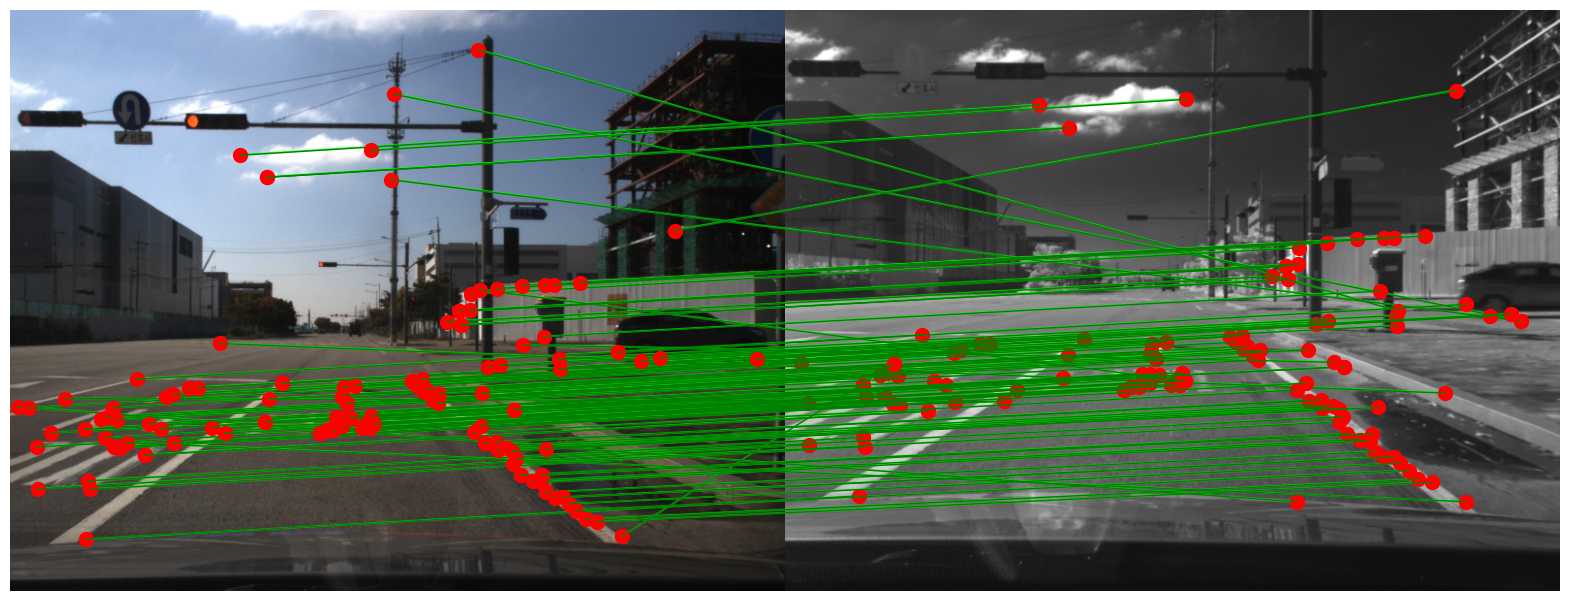

Visualization saved to: /home/michal/Documents/RASMD/alingment_figure/sift_matches.png
Number of good matches: 125


In [33]:
show_sift_matches(
        undist_rgb_path, 
        undist_swir_path,
        output_path_matches,
        target_size=(800, 600),  # Specify desired size for both images
        line_width=1, 
        marker_size=10
    )

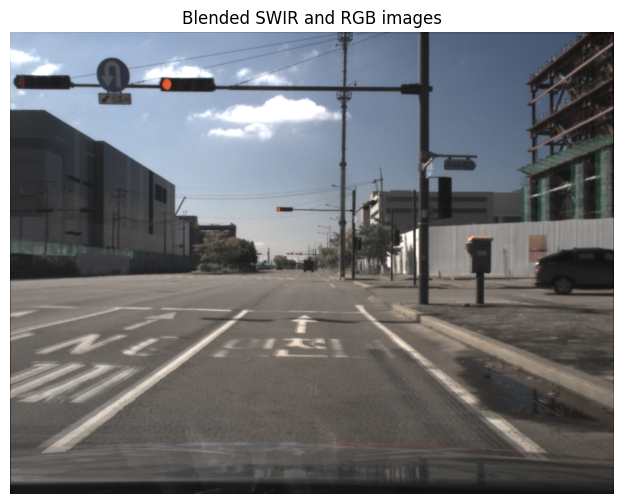

In [34]:
blend_and_display_images(alig_rgb_path, alig_swir_path, output_path_blended, alpha=0.8, beta=0.4)

In [35]:
rgb_imag_orig = cv2.imread(undist_rgb_path)
top, bottom, left, right = 138, 1535, 9, 1835
cv2.rectangle(rgb_imag_orig, (left, top), (right, bottom), (0, 255, 0), 10)
cv2.imwrite(output_path_rectangle, rgb_imag_orig)


True

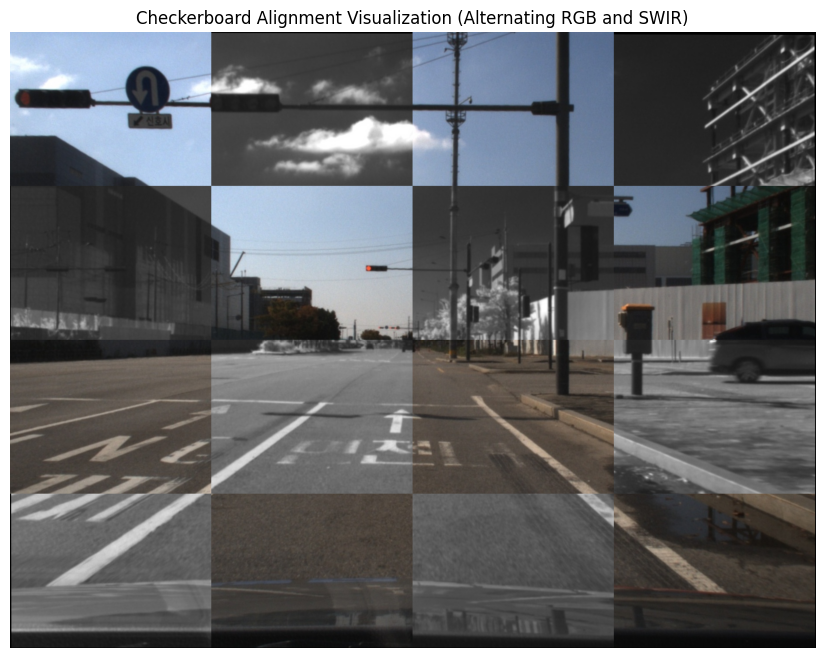

In [36]:
show_checkerboard_alignment(alig_rgb_path, alig_swir_path, output_path_blended, squares_per_row=4)

In [ ]:
show_checkerboard_alignment(alig_rgb_path, alig_swir_path, output_path_blended, squares_per_row=4)